## Investigating optimal pulse duration for minimising CME arrival time/speed errors using OMNI backmapped boundary conditions and MOSWOC Cone CME files

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import copy
from datetime import datetime, timedelta
from astropy.time import Time
from scipy.interpolate import interp1d
from scipy.stats import linregress

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12
})

In [3]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [4]:
def plot_spread_bands(
    ax, x, median, sph_median,
    q1=None, q3=None,
    d1=None, d9=None,
    vmin=None, vmax=None,
    cmap='cool'
):
    """
    Plot spread bands (range + IQR) with median and optional mean.
    """

    # =====================================================
    # FONT SIZES
    # =====================================================

    label_fs = 18
    title_fs = 20
    tick_fs = 14
    legend_fs = 12

    # =====================================================
    # SPREAD BANDS
    # =====================================================

    n_bands = 3
    norm = mpl.colors.Normalize(vmin=0, vmax=max(n_bands, 1))
    band_index = 0

    # --- RANGE ---
    if vmin is not None and vmax is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))

        ax.fill_between(
            x, vmin, vmax,
            color=rgba,
            alpha=0.5,
            label='Range',
            zorder=0
        )

        band_index += 1

    # --- IDR ---
    if d1 is not None and d9 is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))

        ax.fill_between(
            x, d1, d9,
            color=rgba,
            alpha=0.9,
            label='IDR',
            zorder=1
        )

        band_index += 1

    # --- IQR ---
    if q1 is not None and q3 is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))

        ax.fill_between(
            x, q1, q3,
            color=rgba,
            alpha=0.9,
            label='IQR',
            zorder=2
        )

        band_index += 1

    # =====================================================
    # MEDIAN
    # =====================================================

    ax.plot(
        x,
        median,
        color='tab:olive',
        label='Median',
        marker='.',
        zorder=3,
        linewidth=2.5
    )

    # =====================================================
    # FIND BEST PULSE DURATION
    # =====================================================

    f = interp1d(x, median, kind='cubic')

    x_fine = np.linspace(x.min(), x.max(), 500)
    y_fine = f(x_fine)

    best_pulse = x_fine[np.argmin(np.abs(y_fine))]

    # =====================================================
    # REFERENCE LINES
    # =====================================================

    ax.axhline(
        y=0.0,
        color='k',
        linestyle='--',
        linewidth=1.2
    )

    ax.axhline(
        y=sph_median,
        color='orange',
        linestyle='-.',
        linewidth=1.5,
        label='Spheroidal'
    )

    # --- BEST DURATION LINE ---
    best_line = ax.axvline(
        best_pulse,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Best Duration: {best_pulse:.1f} h'
    )

    # =====================================================
    # AXIS FORMATTING
    # =====================================================

    ax.tick_params(axis='both', labelsize=tick_fs)

    # =====================================================
    # KEEP ONLY BEST-DURATION LEGEND
    # =====================================================

    ax.legend(
        handles=[best_line],
        fontsize=legend_fs,
        loc='upper right',
        frameon=True
    )

    return ax

In [5]:
def plot_v_error_boxplot(
    ax,
    df,
    v_cme,
    ylabel,
    cmap_name="viridis"):
    """
    Boxplot of CME error vs v_cme with IQR-based colouring.
    
    Parameters
    ----------
    ax : matplotlib axis
    df : pandas DataFrame (CME x pulse durations or similar, already transposed)
    v_cme : array-like (CME speeds, same length as df rows/columns after transpose)
    ylabel : str
    title : str
    cmap_name : str
    """

    # ---- prepare long-form data ----
    df_T = df.T.copy()
    df_T["v_cme"] = v_cme.values

    df_melted = df_T.melt(
        id_vars="v_cme",
        var_name="PulseDuration",
        value_name="Error"
    )

    # ---- IQR per CME speed ----
    spread = (
        df_melted.groupby("v_cme")["Error"]
        .apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
    )

    norm = mcolors.Normalize(vmin=spread.min(), vmax=spread.max())
    cmap = cm.get_cmap(cmap_name)

    palette = {str(v): cmap(norm(spread[v])) for v in spread.index}

    # ---- plot ----
    sns.boxplot(
        x="v_cme",
        y="Error",
        data=df_melted,
        order=sorted(spread.index),
        palette=palette,
        ax=ax,
        flierprops=dict(
            marker='D',
            markersize=4,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.6
        )
    )

    ax.axhline(0.0, color='r', linestyle='--')

    ax.set_xlabel("V_cme (km/s)", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("IQR of Error")

    return df_melted, spread

In [6]:
def plot_w_error_boxplot(
    ax,
    df,
    ang_width,
    ylabel,
    title,
    cmap_name="viridis"):
    """
    Boxplot of CME error vs v_cme with IQR-based colouring.
    
    Parameters
    ----------
    ax : matplotlib axis
    df : pandas DataFrame (CME x pulse durations or similar, already transposed)
    ang_width : array-like (CME angular widths, same length as df rows/columns after transpose)
    ylabel : str
    title : str
    cmap_name : str
    """

    # ---- prepare long-form data ----
    df_T = tt_nabs_error.T.copy()
    df_T["ang_width"] = ang_width.values
    df_T["CME_ID"] = np.arange(len(df_T))

    df_melted = df_T.melt(
        id_vars=["CME_ID", "ang_width"],
        var_name="PulseDuration",
        value_name="Error"
    )
    
    order = (df_T.sort_values("ang_width")["CME_ID"])
    
    # ---- IQR per CME ----
    spread = (
        df_melted.groupby("CME_ID")["Error"]
        .apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25)))

    norm = mcolors.Normalize(vmin=spread.min(), vmax=spread.max())
    cmap = cm.get_cmap("viridis")

    palette = {cme: cmap(norm(spread[cme])) for cme in spread.index}
    colors = [cmap(norm(spread[int(cme)])) for cme in order]

    sns.boxplot(
        x="CME_ID",
        y="Error",
        data=df_melted,
        order=order,
        palette=colors,   # ← list instead of dict
        ax=ax,
        flierprops=dict(
            marker='D',
            markersize=4,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.6
        )
    )

    # Get sorted angular widths (aligned with your order)
    labels = (df_T.sort_values("ang_width")["ang_width"].values)

    # Apply them to the axis
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)

    ax.axhline(0.0, color='r', linestyle='--')

    ax.set_xlabel("Half angular width (degrees)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("IQR of Error")

    return df_melted, spread

# Load in data

In [7]:
# Load dataset
df_tt = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output/cme_transit_time.csv",header=None)
df_av = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output/cme_arrival_speed.csv",header=None)
mas_df_tt = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output_MAS/cme_transit_time.csv",header=None)
mas_df_av = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output_MAS/cme_arrival_speed.csv",header=None)
wsa_df_tt = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output_WSA/cme_transit_time.csv",header=None)
wsa_df_av = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output_WSA/cme_arrival_speed.csv",header=None)
crlist = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/input/(I)CMEs.csv")

In [8]:
# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5','Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# Add observed values to the arrival speed dataframe
new_rows = ['V_max', 'V_max_smooth']

rows=[]

for row in new_rows:
    data = [row] + crlist[row].tolist()
    rows.append(data)

combined_df = pd.DataFrame(rows)

df_tt = pd.concat([combined_df, df_tt], ignore_index=True)
df_av = pd.concat([combined_df, df_av], ignore_index=True)
mas_df_tt = pd.concat([combined_df, mas_df_tt], ignore_index=True)
mas_df_av = pd.concat([combined_df, mas_df_av], ignore_index=True)
wsa_df_tt = pd.concat([combined_df, wsa_df_tt], ignore_index=True)
wsa_df_av = pd.concat([combined_df, wsa_df_av], ignore_index=True)

In [9]:
# Rename first column by rounding its values to 1 decimal place (excluding the first six rows which are CME parameters)
df_tt.iloc[6:, 0] = df_tt.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)
df_av.iloc[6:, 0] = df_av.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)
mas_df_tt.iloc[6:, 0] = mas_df_tt.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)
mas_df_av.iloc[6:, 0] = mas_df_av.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)
wsa_df_tt.iloc[6:, 0] = wsa_df_tt.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)
wsa_df_av.iloc[6:, 0] = wsa_df_av.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)

# Find all columns that have any NaN in either dataframe
cols_with_nan = df_tt.columns[df_tt.isna().any() | df_av.isna().any() | mas_df_tt.isna().any() | 
                                mas_df_av.isna().any() | wsa_df_tt.isna().any() | wsa_df_av.isna().any()]

# Drop those columns from both dataframes
df_tt = df_tt.drop(columns=cols_with_nan)
df_av = df_av.drop(columns=cols_with_nan)
mas_df_tt = mas_df_tt.drop(columns=cols_with_nan)
mas_df_av = mas_df_av.drop(columns=cols_with_nan)
wsa_df_tt = wsa_df_tt.drop(columns=cols_with_nan)
wsa_df_av = wsa_df_av.drop(columns=cols_with_nan)

In [11]:
df_tt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       65 non-null     object 
 1   6       65 non-null     float64
 2   7       65 non-null     float64
 3   8       65 non-null     float64
 4   10      65 non-null     float64
 5   14      65 non-null     float64
 6   15      65 non-null     float64
 7   18      65 non-null     float64
 8   20      65 non-null     float64
 9   21      65 non-null     float64
 10  25      65 non-null     float64
 11  30      65 non-null     float64
 12  31      65 non-null     float64
 13  32      65 non-null     float64
dtypes: float64(13), object(1)
memory usage: 7.2+ KB


# Error Calculations

In [12]:
# Extract pulse duration values (rows), CME transit time data, and CME parameters

tt = df_tt.iloc[6:,1:] # transit time fixed duration
mas_tt = mas_df_tt.iloc[6:,1:] # transit time fixed duration
wsa_tt = wsa_df_tt.iloc[6:,1:] # transit time fixed duration

tt_sph = df_tt.iloc[5,1:] # transit time spheroidal cone cme
mas_tt_sph = mas_df_tt.iloc[5,1:]
wsa_tt_sph = wsa_df_tt.iloc[5,1:]

ang_width = df_tt.iloc[2,1:] # angular width of CMEs
v_cme = df_tt.iloc[3,1:] # velocity of CMEs at 21.5 solRads
tt_obs = df_tt.iloc[4,1:] # observed transit time

pulse_durations = df_tt.iloc[6:, 0] # range of pulse durations
pulse_durations = pulse_durations.astype(float)

In [13]:
print(np.average(tt_obs))
print(np.average(tt))
print(np.average(mas_tt))
print(np.average(wsa_tt))

3.0112179487179485
2.697223498080628
3.355297357404974
2.66271796218021


In [14]:
# Calculate errors in transit time
tt_error = (tt - tt_obs)
tt_sph_error = (tt_sph - tt_obs)

mas_tt_error = (mas_tt - tt_obs)
mas_tt_sph_error = (mas_tt_sph - tt_obs)

wsa_tt_error = (wsa_tt - tt_obs)
wsa_tt_sph_error = (tt_sph - tt_obs)

tt_error = tt_error.apply(pd.to_numeric, errors='coerce')
tt_sph_error = tt_sph_error.apply(pd.to_numeric, errors='coerce')
mas_tt_error = mas_tt_error.apply(pd.to_numeric, errors='coerce')
wsa_tt_error = wsa_tt_error.apply(pd.to_numeric, errors='coerce')
mas_tt_sph_error = mas_tt_sph_error.apply(pd.to_numeric, errors='coerce')
wsa_tt_sph_error = wsa_tt_sph_error.apply(pd.to_numeric, errors='coerce')

In [15]:
# Finding measures of errors
tt_mae = tt_error.mean(axis=1)
tt_median = tt_error.median(axis=1)
tt_q1 = tt_error.quantile(q=0.25,axis=1)
tt_q3 = tt_error.quantile(q=0.75,axis=1)
tt_d1 = tt_error.quantile(q=0.1,axis=1)
tt_d9 = tt_error.quantile(q=0.9,axis=1)
tt_min = tt_error.min(axis=1)
tt_max = tt_error.max(axis=1)

tt_median_sph = tt_sph_error.median()

In [16]:
# Finding measures of errors
mas_tt_mae = mas_tt_error.mean(axis=1)
mas_tt_median = mas_tt_error.median(axis=1)
mas_tt_q1 = mas_tt_error.quantile(q=0.25,axis=1)
mas_tt_q3 = mas_tt_error.quantile(q=0.75,axis=1)
mas_tt_d1 = mas_tt_error.quantile(q=0.1,axis=1)
mas_tt_d9 = mas_tt_error.quantile(q=0.9,axis=1)
mas_tt_min = mas_tt_error.min(axis=1)
mas_tt_max = mas_tt_error.max(axis=1)

mas_tt_median_sph = mas_tt_sph_error.median()

In [17]:
# Finding measures of errors
wsa_tt_mae = wsa_tt_error.mean(axis=1)
wsa_tt_median = wsa_tt_error.median(axis=1)
wsa_tt_q1 = wsa_tt_error.quantile(q=0.25,axis=1)
wsa_tt_q3 = wsa_tt_error.quantile(q=0.75,axis=1)
wsa_tt_d1 = wsa_tt_error.quantile(q=0.1,axis=1)
wsa_tt_d9 = wsa_tt_error.quantile(q=0.9,axis=1)
wsa_tt_min = wsa_tt_error.min(axis=1)
wsa_tt_max = wsa_tt_error.max(axis=1)

wsa_tt_median_sph = wsa_tt_sph_error.median()

In [18]:
# Extract pulse duration values (rows), CME arrival speed data, and CME parameters

av = df_av.iloc[6:,1:] # arrival speed fixed duration
mas_av = mas_df_av.iloc[6:,1:] # arrival speed fixed duration
wsa_av = wsa_df_av.iloc[6:,1:] # arrival speed fixed duration

av_sph = df_av.iloc[5,1:] # arrival speed spheroidal cone cme
mas_av_sph = mas_df_av.iloc[5,1:]
wsa_av_sph = wsa_df_av.iloc[5,1:]

av_obs = df_av.iloc[0,1:] # observed arrival speed using 1h maximum speed
av_obs_smth = df_av.iloc[1,1:] # observed arrival speed using 8h smoothed maximum speed

In [19]:
print(np.average(av_obs))
print(np.average(av_obs_smth))
print(np.average(mas_av))
print(np.average(wsa_av))
print(np.average(av_sph))

490.7692307692308
475.6730769230769
565.1159052020234
737.1483548015735
603.3834128169909


In [20]:
# Calculate errors in arrival speed
av_error = (av - av_obs)
av_sph_error = (av_sph - av_obs)

mas_av_error = (mas_av - av_obs)
mas_av_sph_error = (mas_av_sph - av_obs)

wsa_av_error = (wsa_av - av_obs)
wsa_av_sph_error = (av_sph - av_obs)

av_error = av_error.apply(pd.to_numeric, errors='coerce')
av_sph_error = av_sph_error.apply(pd.to_numeric, errors='coerce')
mas_av_error = mas_av_error.apply(pd.to_numeric, errors='coerce')
wsa_av_error = wsa_av_error.apply(pd.to_numeric, errors='coerce')
mas_av_sph_error = mas_av_sph_error.apply(pd.to_numeric, errors='coerce')
wsa_av_sph_error = wsa_av_sph_error.apply(pd.to_numeric, errors='coerce')

In [21]:
# Finding measures of errors
av_mae = av_error.mean(axis=1)
av_median = av_error.median(axis=1)
av_q1 = av_error.quantile(q=0.25,axis=1)
av_q3 = av_error.quantile(q=0.75,axis=1)
av_d1 = av_error.quantile(q=0.1,axis=1)
av_d9 = av_error.quantile(q=0.9,axis=1)
av_min = av_error.min(axis=1)
av_max = av_error.max(axis=1)

av_median_sph = av_sph_error.median()

In [22]:
# Finding measures of errors
mas_av_mae = mas_av_error.mean(axis=1)
mas_av_median = mas_av_error.median(axis=1)
mas_av_q1 = mas_av_error.quantile(q=0.25,axis=1)
mas_av_q3 = mas_av_error.quantile(q=0.75,axis=1)
mas_av_d1 = mas_av_error.quantile(q=0.1,axis=1)
mas_av_d9 = mas_av_error.quantile(q=0.9,axis=1)
mas_av_min = mas_av_error.min(axis=1)
mas_av_max = mas_av_error.max(axis=1)

mas_av_median_sph = mas_av_sph_error.median()

In [23]:
# Finding measures of errors
wsa_av_mae = wsa_av_error.mean(axis=1)
wsa_av_median = wsa_av_error.median(axis=1)
wsa_av_q1 = wsa_av_error.quantile(q=0.25,axis=1)
wsa_av_q3 = wsa_av_error.quantile(q=0.75,axis=1)
wsa_av_d1 = wsa_av_error.quantile(q=0.1,axis=1)
wsa_av_d9 = wsa_av_error.quantile(q=0.9,axis=1)
wsa_av_min = wsa_av_error.min(axis=1)
wsa_av_max = wsa_av_error.max(axis=1)

wsa_av_median_sph = wsa_av_sph_error.median()

# Error distribution for each pulse duration

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3327171.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3327171.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3327171.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyp

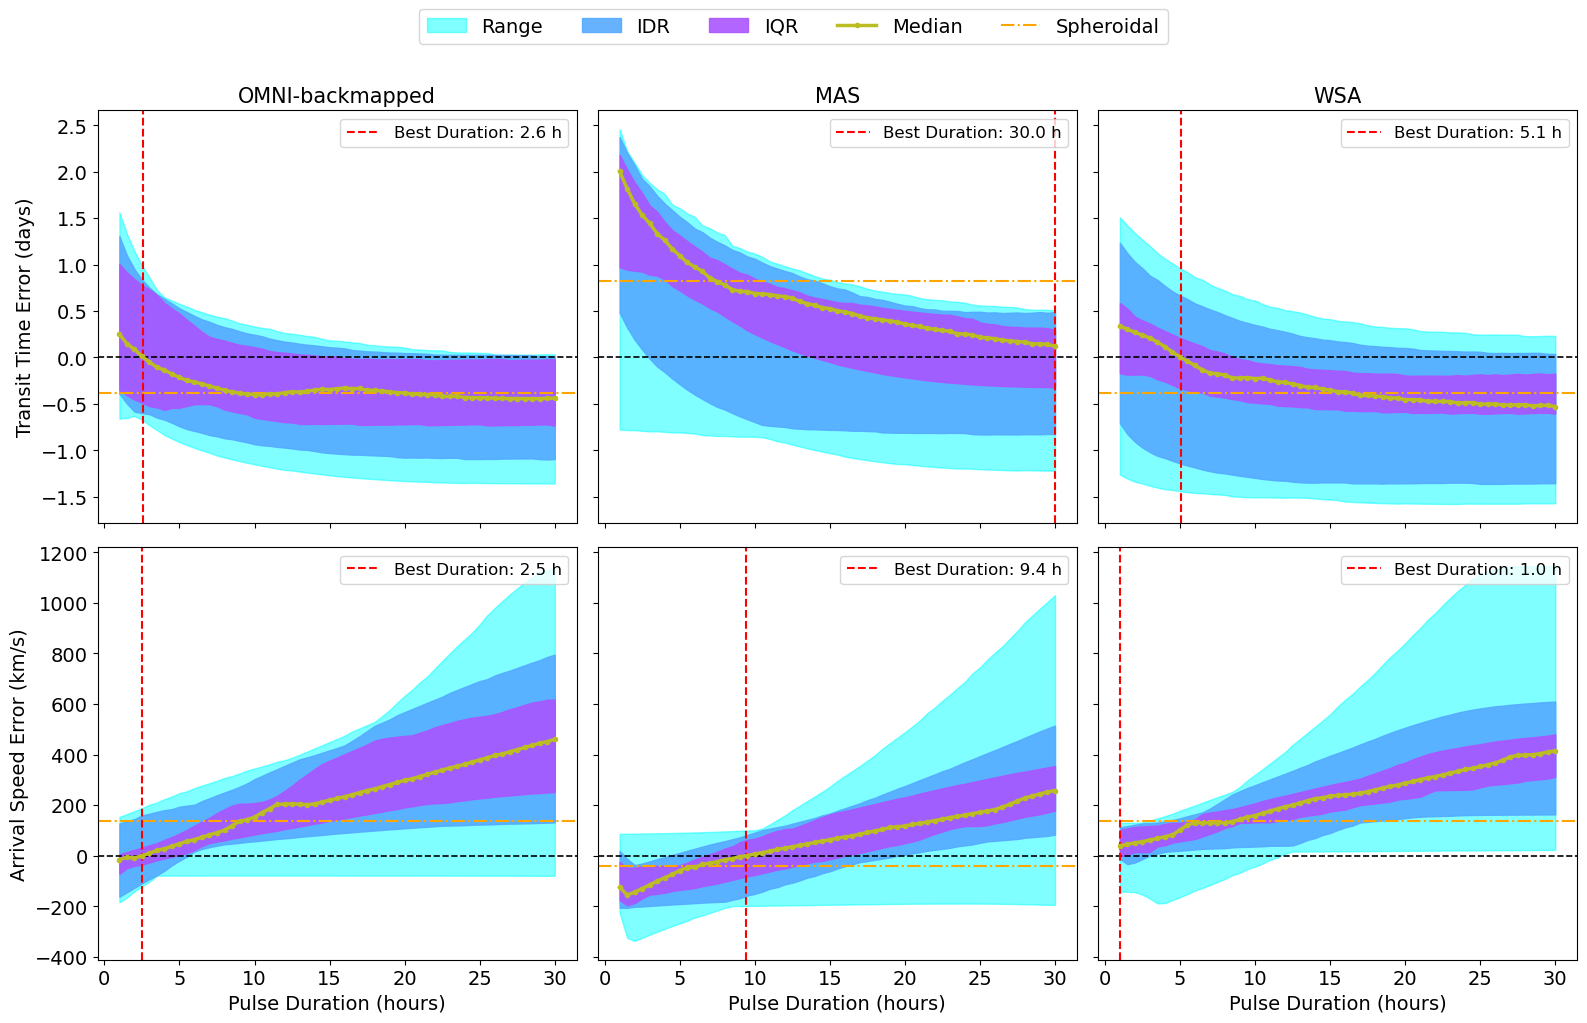

In [24]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    sharex=True,
    sharey='row'   # shared y-axis within each row
)

# =====================================================
# TOP ROW — TRANSIT TIME ERRORS
# =====================================================

# ---------- Original ----------
plot_spread_bands(axes[0, 0],pulse_durations,median=tt_median,sph_median=tt_median_sph,q1=tt_q1,q3=tt_q3,
    d1=tt_d1,d9=tt_d9,vmin=tt_min,vmax=tt_max)

axes[0, 0].set_title('OMNI-backmapped')
axes[0, 0].set_ylabel('Transit Time Error (days)')


# ---------- MAS ----------
plot_spread_bands(axes[0, 1],pulse_durations,median=mas_tt_median,sph_median=mas_tt_median_sph,q1=mas_tt_q1,q3=mas_tt_q3,
    d1=mas_tt_d1,d9=mas_tt_d9,vmin=mas_tt_min,vmax=mas_tt_max)

axes[0, 1].set_title('MAS')


# ---------- WSA ----------
plot_spread_bands(axes[0, 2],pulse_durations,median=wsa_tt_median,sph_median=wsa_tt_median_sph,q1=wsa_tt_q1,q3=wsa_tt_q3,
    d1=wsa_tt_d1,d9=wsa_tt_d9,vmin=wsa_tt_min,vmax=wsa_tt_max)

axes[0, 2].set_title('WSA')


# =====================================================
# BOTTOM ROW — ARRIVAL SPEED ERRORS
# =====================================================

# ---------- Original ----------
plot_spread_bands(axes[1, 0],pulse_durations,median=av_median,sph_median=av_median_sph,q1=av_q1,q3=av_q3,
    d1=av_d1,d9=av_d9,vmin=av_min,vmax=av_max)

axes[1, 0].set_ylabel('Arrival Speed Error (km/s)')
axes[1, 0].set_xlabel('Pulse Duration (hours)')


# ---------- MAS ----------
plot_spread_bands(axes[1, 1],pulse_durations,median=mas_av_median,sph_median=mas_av_median_sph,q1=mas_av_q1,q3=mas_av_q3,
    d1=mas_av_d1,d9=mas_av_d9,vmin=mas_av_min,vmax=mas_av_max)

axes[1, 1].set_xlabel('Pulse Duration (hours)')


# ---------- WSA ----------
plot_spread_bands(axes[1, 2],pulse_durations,median=wsa_av_median,sph_median=wsa_av_median_sph,q1=wsa_av_q1,q3=wsa_av_q3,
    d1=wsa_av_d1,d9=wsa_av_d9,vmin=wsa_av_min,vmax=wsa_av_max)

axes[1, 2].set_xlabel('Pulse Duration (hours)')


# =====================================================
# CREATE SHARED LEGEND (WITHOUT BEST DURATION)
# =====================================================

# Get all handles/labels from first axis
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove "Best Duration" entries from shared legend
filtered = [
    (h, l)
    for h, l in zip(handles, labels)
    if "Best Duration" not in l
]

shared_handles, shared_labels = zip(*filtered)

# Remove duplicates while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(shared_handles, shared_labels):
    if l not in seen:
        unique_handles.append(h)
        unique_labels.append(l)
        seen.add(l)

# Shared legend at top
fig.legend(unique_handles,unique_labels,loc='upper center',bbox_to_anchor=(0.5, 1.03),ncol=5,fontsize=14,frameon=True)

# =====================================================
# FINAL FORMATTING
# =====================================================

fig.tight_layout(rect=[0, 0, 1, 0.96])

filename = "/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/Error_bands.pdf"

fig.savefig(
    filename,
    format="pdf",
    bbox_inches="tight"
)

# Error distribution for each CME arranged by V, ang_width

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3243419867.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3243419867.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3243419867.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000g

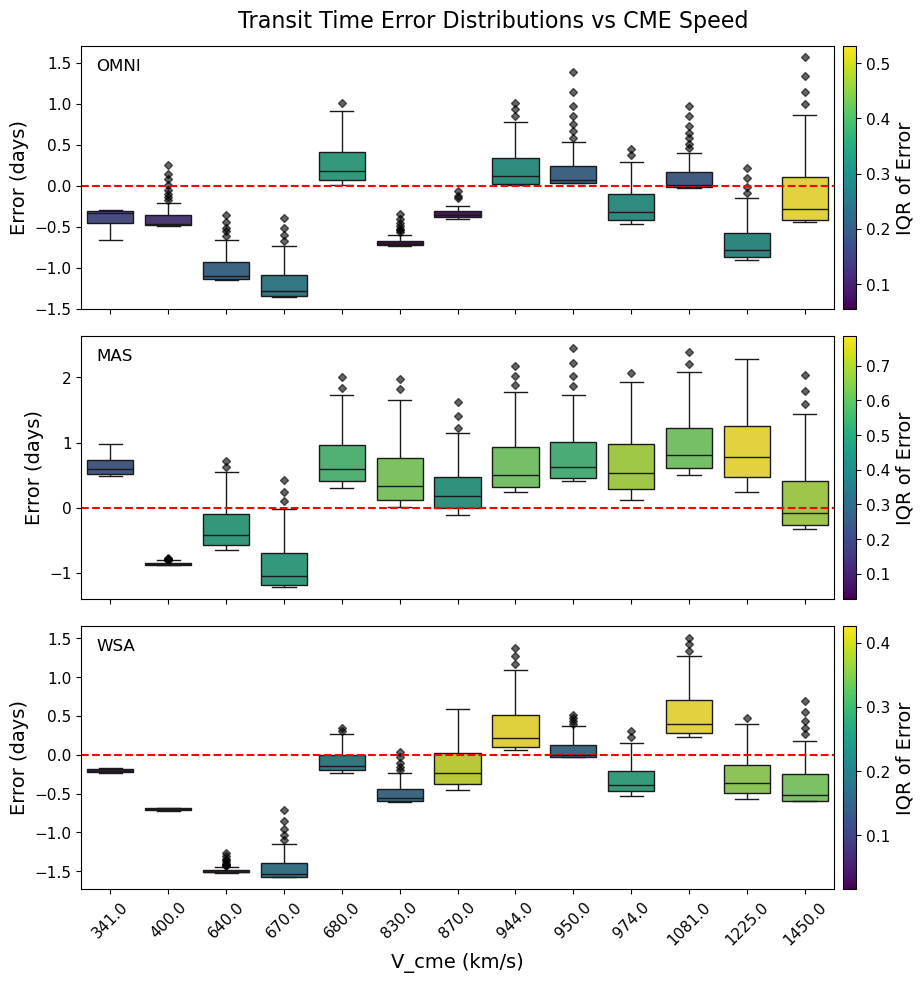

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

df_melted_tt, spread_tt = plot_v_error_boxplot(
    axes[0],
    tt_error,
    v_cme,
    ylabel="Error (days)"
)

df_melted_tt_mas, spread_tt_mas = plot_v_error_boxplot(
    axes[1],
    mas_tt_error,
    v_cme,
    ylabel="Error (days)"
)

df_melted_tt_wsa, spread_tt_wsa = plot_v_error_boxplot(
    axes[2],
    wsa_tt_error,
    v_cme,
    ylabel="Error (days)"
)

axes[2].tick_params(axis='x', labelrotation=45)

# ---- shared title ----
fig.suptitle("Transit Time Error Distributions vs CME Speed", fontsize=16)

# ---- panel labels ----
labels = ["OMNI", "MAS", "WSA"]
for ax, lab in zip(axes, labels):
    ax.text(0.02, 0.95, lab,
            transform=ax.transAxes,
            fontsize=12,
            va='top')

# ---- layout ----
fig.tight_layout(rect=[0, 0, 1, 1])

fig.subplots_adjust(hspace=0.1)

fig.savefig(
    "/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/tt_error_vs_vcme.pdf",
    bbox_inches="tight"
)

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3243419867.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3243419867.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_44398/3243419867.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000g

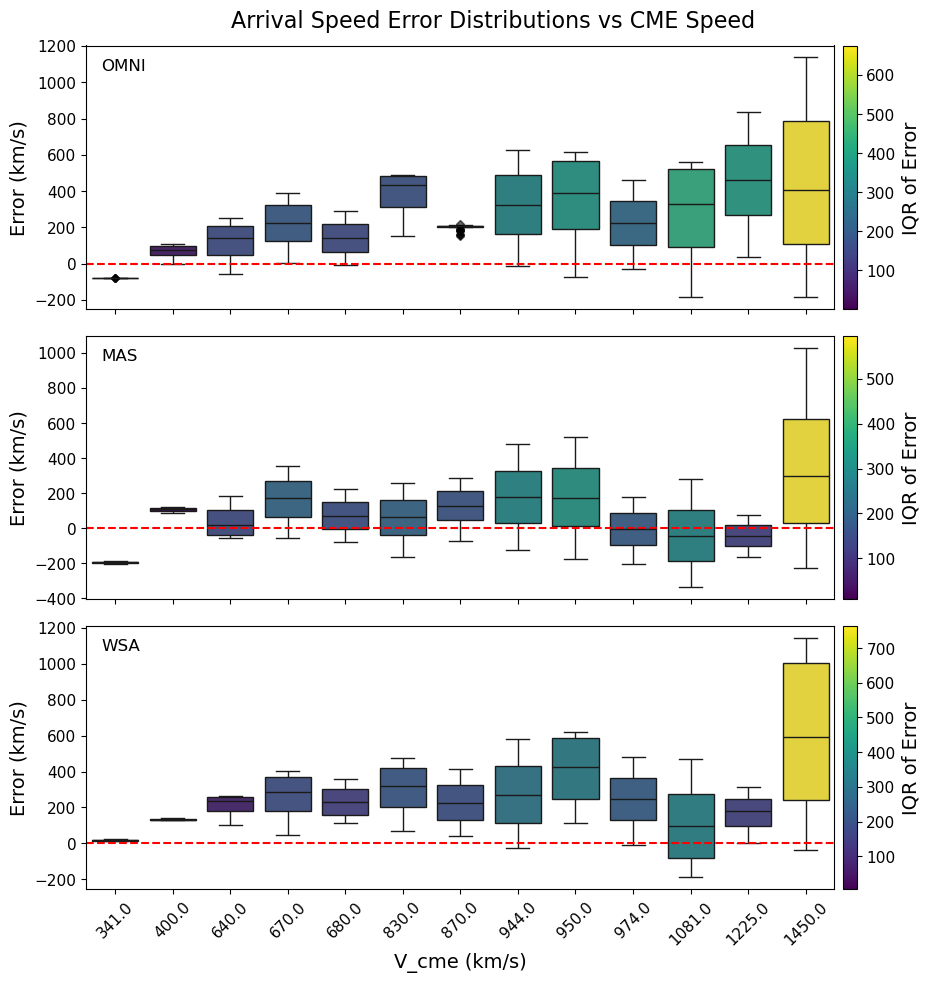

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

df_melted_av, spread_av = plot_v_error_boxplot(
    axes[0],
    av_error,
    v_cme,
    ylabel="Error (km/s)"
)

df_melted_av_mas, spread_av_mas = plot_v_error_boxplot(
    axes[1],
    mas_av_error,
    v_cme,
    ylabel="Error (km/s)"
)

df_melted_av_wsa, spread_av_wsa = plot_v_error_boxplot(
    axes[2],
    wsa_av_error,
    v_cme,
    ylabel="Error (km/s)"
)

axes[2].tick_params(axis='x', labelrotation=45)

# ---- shared title ----
fig.suptitle("Arrival Speed Error Distributions vs CME Speed", fontsize=16)

# ---- panel labels ----
labels = ["OMNI", "MAS", "WSA"]
for ax, lab in zip(axes, labels):
    ax.text(0.02, 0.95, lab,
            transform=ax.transAxes,
            fontsize=12,
            va='top')

# ---- layout ----
fig.tight_layout(rect=[0, 0, 1, 1])

fig.subplots_adjust(hspace=0.1)

fig.savefig(
    "/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/av_error_vs_vcme.pdf",
    bbox_inches="tight"
)

# Both 

NameError: name 'tt_median_sph_nabs' is not defined

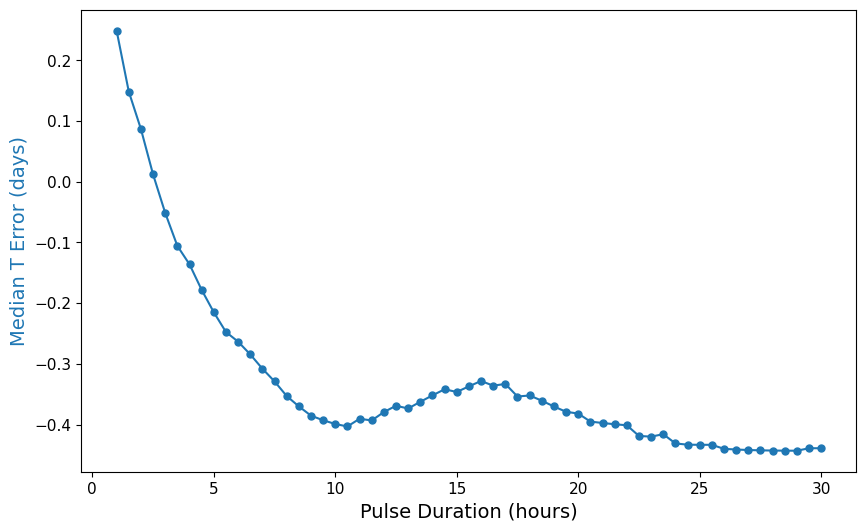

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: Transit Time Error
color1 = 'tab:blue'
ax1.set_xlabel('Pulse Duration (hours)', fontsize=14)
ax1.set_ylabel('Median T Error (days)', color=color1, fontsize=14)
line1 = ax1.plot(pulse_durations, tt_median, marker='o', markersize=5, linestyle='-', color=color1, label='T')
ax1.axhline(y=tt_median_sph_nabs, color=color1, linestyle='--', label='T_spheroidal')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=13)
ax1.tick_params(axis='x', labelsize=13)
ax1.set_xticks(np.arange(min(pulse_durations), max(pulse_durations) + 1, 2))

# Right y-axis: Arrival Speed Error
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Median V Error (km/s)', color=color2, fontsize=14)
line2 = ax2.plot(pulse_durations, av_median, marker='o', markersize=5, linestyle='-', color=color2, label='V_1h')
ax2.axhline(y=av_median_sph, color=color2, linestyle='--', label='V_spheroidal')
ax2.axhline(y=0.0, color='black', linestyle='-.')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=13)

# Add speed errors calculated using smoothed data
color3 = 'tab:olive'
line3 = ax2.plot(pulse_durations, av_median_smth, marker='o', markersize=5, linestyle='-', color=color3, label='V_8h_smoothed')
ax2.axhline(y=av_median_sph_smth, color=color3, linestyle='--', label='V_sphe_8h')

# Add vertical lines at intersections (or closest match)
ax1.axvline(11.3, color='black', linestyle='--', linewidth=1)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center left',
    bbox_to_anchor=(1.2, 0.5),
    borderaxespad=0,
    frameon=False
)

ax1.set_ylim(-1.0,1.0)
ax2.set_ylim(-100,100)

# Save and show
filename = ("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/error_vs_pulse_duration_combined.pdf")
fig.tight_layout()
fig.savefig(filename, format="pdf", bbox_inches="tight")

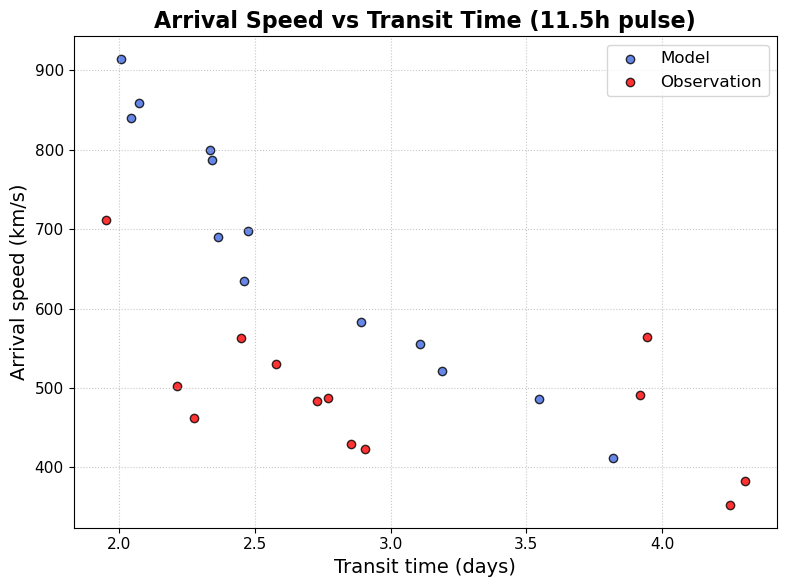

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(tt.iloc[21, :],av.iloc[21, :],color='royalblue', edgecolor='black', label='Model', alpha=0.8)
plt.scatter(tt_obs,av_obs,color='red', edgecolor='black', label='Observation', alpha=0.8)
plt.xlabel('Transit time (days)', fontsize=14)
plt.ylabel('Arrival speed (km/s)', fontsize=14)
plt.title('Arrival Speed vs Transit Time (11.5h pulse)', fontsize=16, weight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
filename = ("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/tt_av_11.pdf")
plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.show()

In [33]:
print(pulse_durations.iloc[3])

2.5


In [30]:
# Ensure v_cme is in a 1D format
v_cme_values = v_cme.values.flatten()
v_cme_values = v_cme_values.astype(float)

y = 0.0157 * v_cme_values + 2.1151

pulse = np.round(y / 0.5) * 0.5
pulse = np.round(pulse, 2)
print(pulse)

row_map = {v: i for i, v in enumerate(pulse_durations.values)}
row_idx = np.array([row_map[p] for p in pulse])
print(row_idx)

col_idx = np.arange(tt_nabs_error.shape[1])
print(col_idx)

result = pd.Series(
    tt_nabs_error.to_numpy()[row_idx, col_idx]
)
print(result)

[19.  17.  25.  16.  15.  21.5  8.5 17.5  7.5 17.  12.5 13.  12. ]
[36 32 48 30 28 41 15 33 13 32 23 24 22]


NameError: name 'tt_nabs_error' is not defined

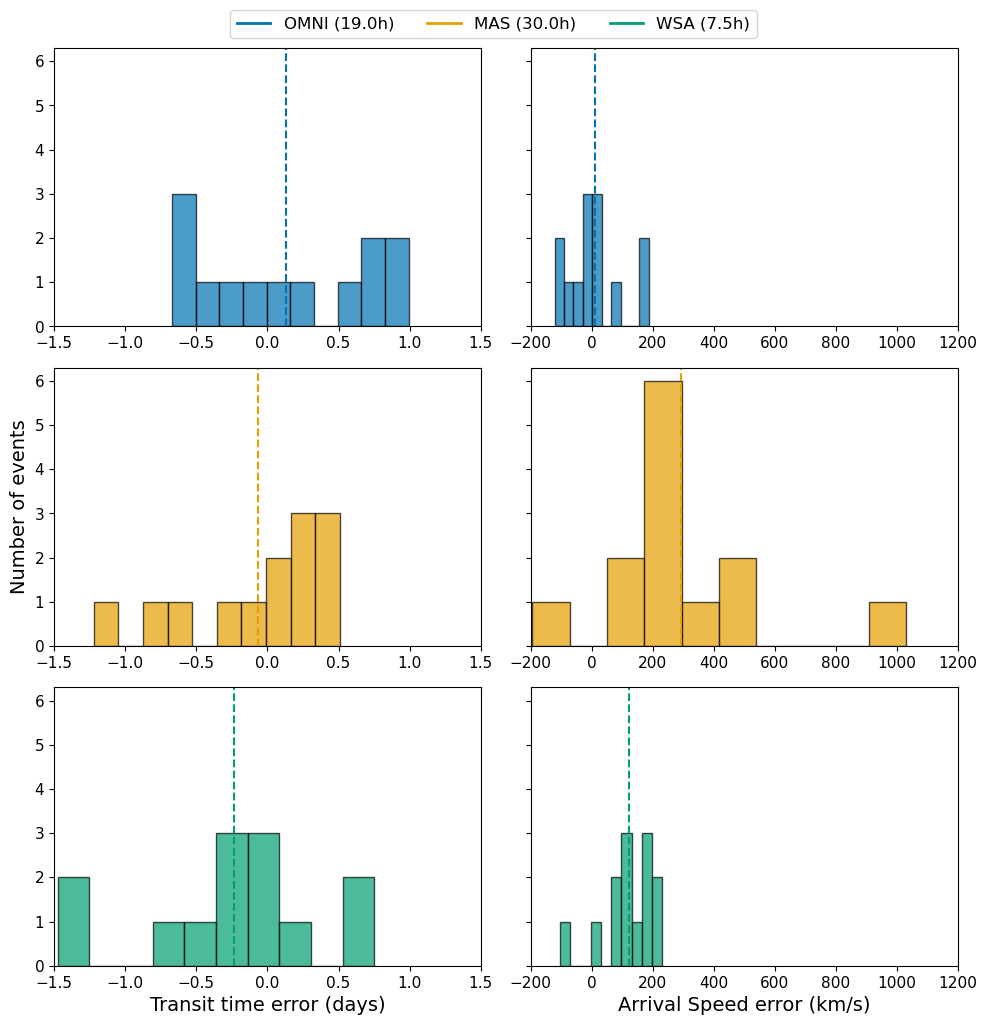

In [34]:
fig, ax = plt.subplots(3,2,figsize=(10, 10),sharey=True)

# define colours
c_omni = "#0072B2"
c_mas  = "#E69F00"
c_wsa  = "#009E73"

# histograms
ax[0,0].hist(tt_error.iloc[3, :], alpha=0.7, color=c_omni, edgecolor='black', label='OMNI (2.5h)')
ax[1,0].hist(mas_tt_error.iloc[58, :], alpha=0.7, color=c_mas, edgecolor='black', label='MAS (30.0h)')
ax[2,0].hist(wsa_tt_error.iloc[13, :], alpha=0.7, color=c_wsa, edgecolor='black', label='WSA (7.5h)')

# means (same colours)
ax[0,0].axvline(np.mean(tt_error.iloc[3, :]), color=c_omni, linestyle='--')
ax[1,0].axvline(np.mean(mas_tt_error.iloc[58, :]), color=c_mas, linestyle='--')
ax[2,0].axvline(np.mean(wsa_tt_error.iloc[13, :]), color=c_wsa, linestyle='--')

ax[2,0].set_xlabel("Transit time error (days)")
ax[1,0].set_ylabel("Number of events")

ax[0,0].set_xlim(-1.5,1.5)
ax[1,0].set_xlim(-1.5,1.5)
ax[2,0].set_xlim(-1.5,1.5)

# histograms
ax[0,1].hist(av_error.iloc[3, :], alpha=0.7, color=c_omni, edgecolor='black', label='OMNI (2.5h)')
ax[1,1].hist(mas_av_error.iloc[58, :], alpha=0.7, color=c_mas, edgecolor='black', label='MAS (30.0h)')
ax[2,1].hist(wsa_av_error.iloc[13, :], alpha=0.7, color=c_wsa, edgecolor='black', label='WSA (7.5h)')

# means (same colours)
ax[0,1].axvline(np.mean(av_error.iloc[3, :]), color=c_omni, linestyle='--')
ax[1,1].axvline(np.mean(mas_av_error.iloc[58, :]), color=c_mas, linestyle='--')
ax[2,1].axvline(np.mean(wsa_av_error.iloc[13, :]), color=c_wsa, linestyle='--')

ax[2,1].set_xlabel("Arrival Speed error (km/s)")

ax[0,1].set_xlim(-200,1200)
ax[1,1].set_xlim(-200,1200)
ax[2,1].set_xlim(-200,1200)

handles = [
    plt.Line2D([0], [0], color=c_omni, lw=2, label='OMNI (19.0h)'),
    plt.Line2D([0], [0], color=c_mas, lw=2, label='MAS (30.0h)'),
    plt.Line2D([0], [0], color=c_wsa, lw=2, label='WSA (7.5h)')
]

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.95])

filename = ("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/optimal_duration_comparison.pdf")
fig.tight_layout()
fig.savefig(filename, format="pdf", bbox_inches="tight")

In [32]:
def abs_error():
    fixed = tt_nabs_error.iloc[21, :]
    fixed = fixed.abs()
    mean_fixed = fixed.mean()

    reg = result.abs()
    mean_reg = reg.mean()

    print('Mean absolute error for 12h fixed pulse:', mean_fixed)
    print('Mean absolute error for linear regression-picked pulse;', mean_reg)

abs_error()

Mean absolute error for 12h fixed pulse: 0.6092011442977108
Mean absolute error for linear regression-picked pulse; 0.5296043475139112
